# OpenAlex from Python: green and circular-economy science in five blocks

**DAISY 2026 summer school, Taranto. Session "Publications as innovation data: measuring (green) science with OpenAlex, at scale with BigQuery"** (Massimiliano Coda Zabetta)

Questions about the circular-economy literature asked to the OpenAlex REST API from Python with `pyalex` (J. de Bruin, github.com/J535D165/pyalex), `pandas` and `matplotlib`. This is the twin of `daisy_openalex_api_R.ipynb`: same blocks, same calls, same numbers.

Blocks: **B0** anatomy of a record and cost, **B1** trend, **B2** geography and RCA, **B3** SDG landscape and priorities.

Each block has: **concept** (what and why), **code** (commented, with the Stata equivalent where one exists), **interpret** (what the output says), **exercise** (one line to try after the session).

Runtime: Colab, Python 3 (the default). Cells run top to bottom; nothing is loaded from disk. Written for pyalex 0.21 or later.

## Setup: packages and API key

Since February 2026 the OpenAlex API expects a key for anything beyond light demo use. The key is free: log in at [openalex.org/settings/api](https://openalex.org/settings/api), copy it.

- With a key: 1 USD of usage per day. A list, filter or group_by call costs 0.0001 USD, a text search 0.001 USD, a single-record lookup nothing.
- Without a key: 0.10 USD per day, about 1,000 calls, enough to run this notebook once.
- Every response carries `meta.cost_usd`, so the price of a call is always visible.

This notebook makes about 320 calls, roughly 0.03 USD; almost all of them are the two uncapped institution downloads of B2 (every page of 200 groups is one call). Keyless still fits one full run.

`pyalex` 0.21 or later has `pyalex.config.api_key`; the first cell upgrades the package (Colab ships an older one or none).

In [ ]:
# Upgrade to the current pyalex (0.21 or later); a restart is not needed. The comment sits on its own line because on
# Windows a trailing "# ..." on a %pip line is passed to pip as arguments.
%pip install -U pyalex -q

In [2]:
import pyalex                                    # Python client for the OpenAlex API
from pyalex import Works, Institutions, Topics   # one class per entity
import pandas as pd                              # tables (Stata: the dataset in memory)
import matplotlib.pyplot as plt                  # charts

print(pyalex.__version__)                        # should print 0.21 or later

# Your OpenAlex key (free at openalex.org/settings/api). Paste it between the quotes;
# left empty, the notebook runs keyless on the small daily budget, enough for one full run.
YOUR_API_KEY = ""

if YOUR_API_KEY:
    pyalex.config.api_key = YOUR_API_KEY         # register it for the session
pyalex.config.email = "you@example.org"          # courtesy contact address (OpenAlex "polite pool")

0.21


## B0. Anatomy of one record

**Concept.** One OpenAlex work is a nested JSON record, and everything a publication dataset can measure is a field of it.

Our example is the standard reference of the circular-economy literature: Kirchherr, Reike and Hekkert (2017, *Resources, Conservation and Recycling*), "Conceptualizing the circular economy: an analysis of 114 definitions", OpenAlex id W2756283300, found with a free lookup by DOI (10.1016/j.resconrec.2017.09.005).

The cells below open the record one group at a time: identity and venue, access and impact, the people, the classifications, the text, the links.

`Works()["W..."]` returns the record as a Python dict; `pd.DataFrame()` turns any list of dicts into a table (Stata: `reshape long`).

In [3]:
# Fetch one work by its OpenAlex id. Single lookups are free; a DOI works too:
# Works()["https://doi.org/10.1016/j.resconrec.2017.09.005"]
paper = Works()["W2756283300"]

# A Python dict, one key per field: the whole record. The cells below open it group by group.
sorted(paper.keys())

['abstract_inverted_index',
 'apc_list',
 'apc_paid',
 'authorships',
 'awards',
 'best_oa_location',
 'biblio',
 'citation_normalized_percentile',
 'cited_by_count',
 'cited_by_percentile_year',
 'concepts',
 'content_urls',
 'corresponding_author_ids',
 'corresponding_institution_ids',
 'countries_distinct_count',
 'counts_by_year',
 'created_date',
 'display_name',
 'doi',
 'funders',
 'fwci',
 'has_content',
 'has_fulltext',
 'id',
 'ids',
 'indexed_in',
 'institutions',
 'institutions_distinct_count',
 'is_paratext',
 'is_retracted',
 'is_xpac',
 'keywords',
 'language',
 'locations',
 'locations_count',
 'mesh',
 'open_access',
 'primary_location',
 'primary_topic',
 'publication_date',
 'publication_year',
 'referenced_works',
 'referenced_works_count',
 'related_works',
 'sustainable_development_goals',
 'title',
 'topics',
 'type',
 'updated_date']

In [4]:
# Identity and venue: what the paper is and where it appeared (Stata: list ... in 1)
print(paper["primary_location"]["source"]["display_name"], "| volume", paper["biblio"]["volume"])

{k: paper[k] for k in ["display_name", "publication_year", "publication_date", "type", "language", "doi"]}

Resources Conservation and Recycling | volume 127


{'display_name': 'Conceptualizing the circular economy: An analysis of 114 definitions',
 'publication_year': 2017,
 'publication_date': '2017-09-15',
 'type': 'article',
 'language': 'en',
 'doi': 'https://doi.org/10.1016/j.resconrec.2017.09.005'}

In [5]:
# Access and impact: open access status, total citations, and the FWCI
# (FWCI = 1 means cited exactly as much as the average paper of the same field and year)
print(paper["open_access"])
print(paper["cited_by_count"], "citations | FWCI", round(paper["fwci"], 1))

# Citations year by year: note the handful dated before publication (online-first copies, dating noise)
pd.DataFrame(paper["counts_by_year"])

{'is_oa': True, 'oa_status': 'hybrid', 'oa_url': 'https://www.sciencedirect.com/science/article/pii/S0921344917302835/pdf', 'any_repository_has_fulltext': True}
8181 citations | FWCI 435.7


,year,cited_by_count
0,2026,1277
1,2025,1449
2,2024,1197
3,2023,1244
4,2022,1064
5,2021,913
6,2020,582
7,2019,311
8,2018,128
9,2017,7


In [6]:
# Authorships: one row per author and institution (Stata: reshape long twice, authors then institutions)
rows = [{"author": a["author"]["display_name"], "position": a["author_position"],
         "institution": i["display_name"], "country": i["country_code"]}
        for a in paper["authorships"] for i in a["institutions"]]

pd.DataFrame(rows)   # one row per author x institution

,author,position,institution,country
0,Julian Kirchherr,first,Utrecht University,NL
1,Denise Reike,middle,Utrecht University,NL
2,Marko P. Hekkert,last,Utrecht University,NL


In [7]:
# The primary topic and its hierarchy: topic, subfield, field, domain
(paper["primary_topic"]["display_name"], paper["primary_topic"]["subfield"]["display_name"],
 paper["primary_topic"]["field"]["display_name"], paper["primary_topic"]["domain"]["display_name"])

('Sustainable Supply Chain Management',
 'Strategy and Management',
 'Business, Management and Accounting',
 'Social Sciences')

In [8]:
# All topics of the paper as a table (a list of dicts becomes rows); the first row is the primary topic
pd.DataFrame(paper["topics"])[["id", "display_name", "score"]]

,id,display_name,score
0,https://openalex.org/T10539,Sustainable Supply Chain Management,0.9998
1,https://openalex.org/T10880,Environmental Sustainability in Business,0.9963
2,https://openalex.org/T12746,Sustainable Industrial Ecology,0.9925


In [9]:
# SDG tags: an empty list here, the classifier kept no goal for this paper, abstract and all (keep this in mind for B3)
paper["sustainable_development_goals"]

[]

In [10]:
# The abstract travels as an inverted index (word -> positions, a legal constraint); pyalex rebuilds the text
paper["abstract"][:300]

'The circular economy concept has gained momentum both among scholars and practitioners. However, critics claim that it means many different things to different people. This paper provides further evidence for these critics. The aim of this paper is to create transparency regarding the current unders'

In [11]:
# The reference list: the works this paper cites, as OpenAlex ids.
# This is the raw material of citation analysis: snowball searches start from it (Works().filter(cites=...)),
# and patent-to-paper links work the same way.
print(len(paper["referenced_works"]), "references")   # 95 (87 resolve to OpenAlex works)
paper["referenced_works"][:5]                         # the first five ids

95 references


['https://openalex.org/W76517323',
 'https://openalex.org/W249670088',
 'https://openalex.org/W831336702',
 'https://openalex.org/W924534388',
 'https://openalex.org/W1255719724']

In [12]:
# The price of a call: ask for one record and read the meta block (count of matches and cost)
res = Works().filter(primary_topic={"id": "T10471"}).get(per_page=1)

res.meta["count"], res.meta["cost_usd"]   # about 105,000 works; 0.0001 USD for a filter call

(105087, 0.0001)

**Interpret.**

- Three authors, one institution, one country: counting is easy here. On papers with several institutions and countries per author, counting becomes a decision, whole or fractional (B2).
- The primary topic is T10539 "Sustainable Supply Chain Management": no OpenAlex topic is named circular economy, which is why B1 builds a set of topics.
- FWCI 436: cited about 436 times the average paper of its field and year. The citation curve is still rising nine years on, and it shows one or two citations dated before publication: online-first copies and dating noise, a first taste of imperfect linkage.
- The SDG list is empty even though the abstract is stored. SDG tags come from a text classifier (an mBERT model built by the Aurora university network) that keeps only goals predicted above a 0.4 threshold, and a paper about definitions does not read like applied SDG-12 text to the model. Classifier fields are estimates, not ground truth (B3).

**Exercise.** Replace the identifier with the DOI of your own paper (or with W1732240353, Ghisellini, Cialani and Ulgiati 2016, the other standard CE review: no abstract stored, and no SDG tag either) and check its topics and SDGs.

## B1. Trend: is climate and circular-economy science growing faster than science?

**Concept.** The question is a share: of everything published in a year, how much is circular-economy science? A share needs two counts per year:

- the **denominator**: all works OpenAlex indexes that year, with no topic filter at all;
- the **numerator**: the same call with one filter added (`primary_topic.id`), so only works filed under our topics are counted.

`group_by = "publication_year"` does the counting on OpenAlex's servers (Stata: `collapse (count), by(year)`, run remotely): 16 rows come back, not 15 million records.

Topic T10471 is "Climate Change Policy and Economics" (about 105,000 works). For circular economy there is no single topic: we search the topic catalogue for the phrase and use the set of topics the search returns. In pyalex a filter is a keyword argument, nested fields are dicts (`primary_topic={"id": ...}`), and values joined with `|` mean OR (one filter takes up to 100 of them).

In [13]:
# The denominator: ALL works OpenAlex indexes, counted by year.
# No filter besides the years: articles, books, datasets, everything in the core corpus.
all_year = pd.DataFrame(Works().filter(publication_year="2010-2025").group_by("publication_year").get())

# What we downloaded: 16 rows, one per year. key = the year, count = how many works.
# The rows arrive sorted by count, not by year; the merge below reorders them.
all_year

,key,key_display_name,count
0,2025,2025,14832306
1,2020,2020,11436882
2,2023,2023,10859856
3,2024,2024,10815648
4,2019,2019,10756016
5,2021,2021,10744249
6,2016,2016,10586590
7,2017,2017,10441518
8,2018,2018,10383042
9,2022,2022,10223592


In [14]:
# A first numerator: the same call, with one filter added
cc_year = pd.DataFrame(Works().filter(primary_topic={"id": "T10471"}, publication_year="2010-2025")
                       .group_by("publication_year").get())

# 4,000 to 5,000 works per year against 10+ million: shares will be small numbers
cc_year.head(3)

,key,key_display_name,count
0,2024,2024,5012
1,2023,2023,4876
2,2025,2025,4817


In [15]:
# Which topics are about the circular economy? Search the topic catalogue.
# The search reads each topic's name, description and keywords; it returns 8 topics.
ce_topics_tbl = pd.DataFrame(Topics().search("circular economy").get())
print(ce_topics_tbl[["display_name", "id", "works_count"]].to_string(index=False))

# The works filter wants bare ids in one OR list ("T10539|T11091|..."):
# strip the URL part, then glue the ids with |
ce_topics = [u.split("/")[-1] for u in ce_topics_tbl["id"]]
ce_or = "|".join(ce_topics)

# The second numerator: CE works by year, the same group_by with the OR list as the filter
ce_year = pd.DataFrame(Works().filter(primary_topic={"id": ce_or}, publication_year="2010-2025")
                       .group_by("publication_year").get())

                                                                       display_name                          id  works_count
                                                Sustainable Supply Chain Management https://openalex.org/T10539        83148
                                                Extraction and Separation Processes https://openalex.org/T11091       137454
                                                 Chemistry and Chemical Engineering https://openalex.org/T13180       161901
Recycling and utilization of industrial and municipal waste in materials production https://openalex.org/T11672        52628
                                          Bioeconomy and Sustainability Development https://openalex.org/T13240        37369
                                                     Sustainable Industrial Ecology https://openalex.org/T12746        36038
                                            Industrial Engineering and Technologies https://openalex.org/T13045        42066


In [16]:
# One small table per series; astype(int) because the API sends the year as text
den    = pd.DataFrame({"year": all_year["key"].astype(int), "all":      all_year["count"]})
num_ce = pd.DataFrame({"year": ce_year["key"].astype(int),  "circular": ce_year["count"]})
num_cc = pd.DataFrame({"year": cc_year["key"].astype(int),  "climate":  cc_year["count"]})

# Merge them 1:1 on year and sort (Stata: merge 1:1 year, twice, then sort)
trend = den.merge(num_ce, on="year").merge(num_cc, on="year").sort_values("year").reset_index(drop=True)

# The two shares, in percent (Stata: gen)
trend["circular_share"] = 100 * trend["circular"] / trend["all"]
trend["climate_share"]  = 100 * trend["climate"]  / trend["all"]

# One row per year; the two _share columns are what the charts draw
trend

,year,all,circular,climate,circular_share,climate_share
0,2010,8142473,10638,4299,0.130648,0.052797
1,2011,8738931,11616,4478,0.132922,0.051242
2,2012,9018865,12515,4271,0.138765,0.047356
3,2013,9465137,13349,4406,0.141033,0.046550
4,2014,10003268,14444,4216,0.144393,0.042146
5,2015,10203868,15311,4446,0.150051,0.043572
6,2016,10586590,14358,4306,0.135624,0.040674
7,2017,10441518,14577,3906,0.139606,0.037408
8,2018,10383042,16160,3921,0.155638,0.037763
9,2019,10756016,17483,3958,0.162542,0.036798


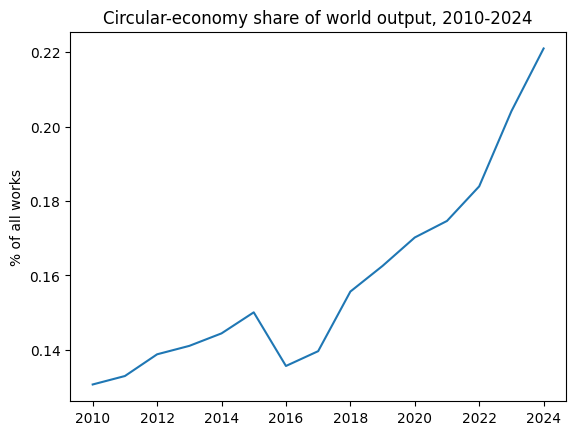

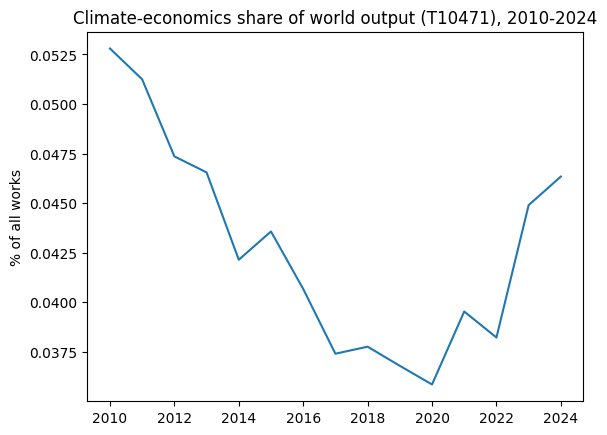

In [17]:
# The charts stop in 2024: the 2025 total is still being ingested (see the table), so its share is not comparable
trend24 = trend[trend["year"] <= 2024]

# One chart per series, same commands with a different y column; separate charts because the two levels
# differ by a factor of four to five, so on one axis the climate line would sit flat at the bottom
plt.plot(trend24["year"], trend24["circular_share"])
plt.ylabel("% of all works")
plt.title("Circular-economy share of world output, 2010-2024")
plt.show()

plt.plot(trend24["year"], trend24["climate_share"])
plt.ylabel("% of all works")
plt.title("Climate-economics share of world output (T10471), 2010-2024")
plt.show()

**Interpret.**

- The circular-economy share of world output nearly doubles: 0.13 percent in 2010 to 0.22 in 2024. The set grows faster than science as a whole.
- The climate-economics share (second chart) does not: it slips from 0.053 to 0.036 percent by 2020 and recovers to 0.046 in 2024. One topic is a narrow net: climate economics also lives in energy, environmental science and policy topics.
- The charts stop in 2024. In the table, the 2025 denominator jumps to 14.8 million works (10.7 in 2024) because ingestion of the year is still under way, so the 2025 shares dip for data reasons, not real ones.
- The level depends on the net. A work has one primary topic; the denominator is the whole core corpus (`corpus=core`, the API default, excludes about 190 million low-metadata "xpac" records on both sides); and the 8 search topics are a narrow, defensible core: an earlier 28-topic keyword rule gave shares three times larger. The definition of the field is a choice; one visible search keeps it honest and repeatable.

**Exercise.** Restrict numerator and denominator to `type = "article"` and see whether the shares change.

## B2. Geography: who specialises in circular-economy science?

**Concept.** Three steps:

1. **count works by country**: `group_by = "authorships.countries"` gives, for each country, the works with at least one author affiliated there (whole counting: a paper with Italian and German authors counts once for each);
2. **put the two counts side by side**: CE works and all works, per country;
3. **divide the shares**: a country's share of world CE output over its share of world output is the **RCA** (revealed comparative advantage, the Balassa index). Above 1: the country publishes more CE science than its size predicts.

The same logic then runs at institution level, and Italian institutions aggregate to regions.

In [18]:
# Step 1: works counted by country of the authors' institutions (whole counting), 2020-2025.
# One call for circular-economy works, one for all works.
ce_country  = pd.DataFrame(Works().filter(primary_topic={"id": ce_or}, publication_year="2020-2025")
                           .group_by("authorships.countries").get())
all_country = pd.DataFrame(Works().filter(publication_year="2020-2025")
                           .group_by("authorships.countries").get())

# What we downloaded: one row per country, largest first. key is a URL like https://openalex.org/countries/IT
ce_country.head(5)
# all_country.head(5)   # uncomment to inspect the denominator too

,key,key_display_name,count
0,https://openalex.org/countries/CN,China,19448
1,https://openalex.org/countries/US,United States,8501
2,https://openalex.org/countries/RU,Russia,7244
3,https://openalex.org/countries/IN,India,6522
4,https://openalex.org/countries/GB,United Kingdom,4539


In [19]:
# Step 2: one clean table per series, with the country code cut out of the key URL
ce_c = pd.DataFrame({"country":      ce_country["key"].str.split("/").str[-1],
                     "country_name": ce_country["key_display_name"],
                     "ce":           ce_country["count"]})

all_c = pd.DataFrame({"country": all_country["key"].str.split("/").str[-1],
                      "all":     all_country["count"]})

# Merge them 1:1 on country (Stata: merge 1:1 country)
rca_country = ce_c.merge(all_c, on="country")

# The raw counts: who produces CE science, and how big each country is overall
rca_country.sort_values("ce", ascending=False).head(10)

,country,country_name,ce,all
0,CN,China,19448,6697730
1,US,United States,8501,8418857
2,RU,Russia,7244,1128760
3,IN,India,6522,2543049
4,GB,United Kingdom,4539,2286494
5,DE,Germany,4253,1913136
6,BR,Brazil,4166,1526017
7,FR,France,3612,1650440
8,IT,Italy,3387,1361630
9,ES,Spain,2537,1144760


In [20]:
# Step 3: shares, then their ratio
rca_country["ce_share"]  = 100 * rca_country["ce"]  / rca_country["ce"].sum()    # share of world CE output
rca_country["all_share"] = 100 * rca_country["all"] / rca_country["all"].sum()   # share of world output
rca_country["rca"] = rca_country["ce_share"] / rca_country["all_share"]          # the RCA: above 1 = specialised

# The same 10 countries, now with shares and RCA next to the raw counts
rca_country = rca_country.sort_values("ce", ascending=False).reset_index(drop=True)
rca_country.head(10)

,country,country_name,ce,all,ce_share,all_share,rca
0,CN,China,19448,6697730,16.630324,13.021534,1.277140
1,US,United States,8501,8418857,7.269353,16.367700,0.444128
2,RU,Russia,7244,1128760,6.194471,2.194503,2.822722
3,IN,India,6522,2543049,5.577076,4.944123,1.128021
4,GB,United Kingdom,4539,2286494,3.881378,4.445336,0.873135
5,DE,Germany,4253,1913136,3.636815,3.719464,0.977779
6,BR,Brazil,4166,1526017,3.562419,2.966838,1.200746
7,FR,France,3612,1650440,3.088684,3.208738,0.962585
8,IT,Italy,3387,1361630,2.896283,2.647242,1.094076
9,ES,Spain,2537,1144760,2.169433,2.225610,0.974759


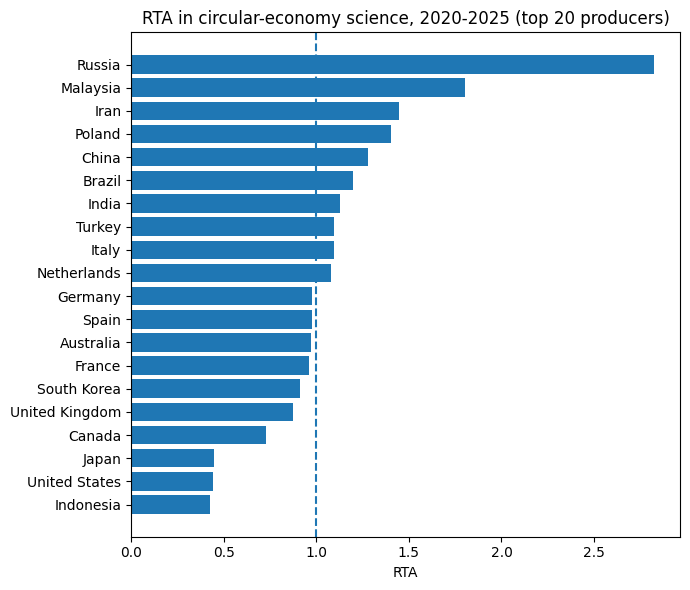

In [21]:
# Bar chart: the 20 largest CE producers, ordered by RCA; the dashed line (RCA = 1) separates specialised from not
top20 = rca_country.head(20).sort_values("rca")

plt.figure(figsize=(7, 6))
plt.barh(top20["country_name"], top20["rca"])
plt.axvline(1, linestyle="--")
plt.title("RCA in circular-economy science, 2020-2025 (top 20 producers)")
plt.xlabel("RCA")
plt.tight_layout(); plt.show()

### Italian regions

Institutions, not countries, carry the fine-grained location: an institution record has a `geo` block with city and region. Three steps:

1. count works by institution: CE works and all works, both restricted to papers with at least one Italian institution;
2. attach each institution's region from its `geo` block;
3. sum by region and compute the same RCA as before, with Italy itself as the reference (RCA = 1).

Step 1 downloads a lot. A `group_by` answer arrives in pages of 200 groups; `pyalex` returns only the first page by default, so here `paginate()` walks through all the pages, about 2,400 institution groups for the CE query and 57,000+ for the all-works one (foreign co-author institutions included), a few minutes in total. We accept the wait and get complete counts, the same ones the R twin downloads.

In [22]:
# All institution groups, no cap: paginate() walks through every page of 200 groups.
# The CE query has about 2,400 groups (about a minute); the all-works query 57,000+ (a few minutes).
pages = (Works().filter(authorships={"institutions": {"country_code": "IT"}},
                        primary_topic={"id": ce_or}, publication_year="2020-2025")
         .group_by("authorships.institutions.id").paginate(per_page=200, n_max=None))
ce_inst = pd.DataFrame([g for page in pages for g in page])

pages = (Works().filter(authorships={"institutions": {"country_code": "IT"}},
                        publication_year="2020-2025")
         .group_by("authorships.institutions.id").paginate(per_page=200, n_max=None))
all_inst = pd.DataFrame([g for page in pages for g in page])

# What we downloaded, largest first (some totals look inflated: institution disambiguation noise)
all_inst.sort_values("count", ascending=False).head(5)

,key,key_display_name,count
5522,https://openalex.org/I189158943,University of Milan,198377
57454,https://openalex.org/I93860229,Politecnico di Milano,174276
36944,https://openalex.org/I4210136779,"Istituto Nazionale di Fisica Nucleare, Sezione...",133089
1816,https://openalex.org/I1299204452,Oeschger Centre for Climate Change Research,129946
56667,https://openalex.org/I861853513,Sapienza University of Rome,81719


In [23]:
# The 200 largest Italian institutions with their geo block (city, region), in one page
inst_it = Institutions().filter(country_code="IT").sort(works_count="desc").select(["id", "display_name", "geo"]).get(per_page=200)

inst_geo = pd.DataFrame([{"key": i["id"], "institution": i["display_name"],
                          "city": (i["geo"] or {}).get("city"), "region": (i["geo"] or {}).get("region")}
                         for i in inst_it])

# The data problem, before any fix: institutions with a city but no region (81 of the 200)
print(inst_geo["region"].isna().sum(), "of 200 institutions have a city but no region")
inst_geo[inst_geo["region"].isna()].head(10)

81 of 200 institutions have a city but no region


,key,institution,city,region
17,https://openalex.org/I900890020,University of Palermo,Palermo,None
22,https://openalex.org/I124601658,University of Parma,Parma,None
24,https://openalex.org/I119439378,University of Verona,Verona,None
25,https://openalex.org/I193223587,University of Trento,Trento,None
26,https://openalex.org/I102064193,University of Siena,Siena,None
30,https://openalex.org/I112862951,University of Messina,Messina,None
32,https://openalex.org/I79940851,University of Brescia,Brescia,None
33,https://openalex.org/I26415053,University of L'Aquila,L’Aquila,None
34,https://openalex.org/I154387261,Vita-Salute San Raffaele University,Milan,None
36,https://openalex.org/I45204951,University of Calabria,Rende,None


In [24]:
# The fix: a city-to-region lookup covering the cities of these 200 institutions (OpenAlex spelling of the regions)
city_region = {
  "Ancona": "The Marches", "Aviano": "Friuli Venezia Giulia", "Bari": "Apulia", "Benevento": "Campania",
  "Bergamo": "Lombardy", "Bologna": "Emilia-Romagna", "Bolzano": "Trentino-Alto Adige", "Brescia": "Lombardy",
  "Cagliari": "Sardinia", "Camerino": "The Marches", "Campobasso": "Molise", "Candiolo": "Piedmont",
  "Caserta": "Campania", "Cassino": "Lazio", "Catania": "Sicily", "Catanzaro": "Calabria",
  "Chieti": "Abruzzo", "Enna": "Sicily", "Ferrara": "Emilia-Romagna", "Fisciano": "Campania",
  "Florence": "Tuscany", "Foggia": "Apulia", "Frascati": "Lazio", "Genoa": "Liguria",
  "Ispra": "Lombardy", "Lavagna": "Liguria", "Lecce": "Apulia", "Legnaro": "Veneto",
  "L’Aquila": "Abruzzo", "L'Aquila": "Abruzzo", "Macerata": "The Marches", "Meldola": "Emilia-Romagna",
  "Messina": "Sicily", "Milan": "Lombardy", "Modena": "Emilia-Romagna", "Monserrato": "Sardinia",
  "Monza": "Lombardy", "Naples": "Campania", "Padua": "Veneto", "Palermo": "Sicily",
  "Parma": "Emilia-Romagna", "Pavia": "Lombardy", "Perugia": "Umbria", "Pino Torinese": "Piedmont",
  "Pisa": "Tuscany", "Potenza": "Basilicata", "Pozzilli": "Molise", "Reggio Calabria": "Calabria",
  "Reggio Emilia": "Emilia-Romagna", "Rende": "Calabria", "Rome": "Lazio", "Rozzano": "Lombardy",
  "San Donato Milanese": "Lombardy", "San Giovanni Rotondo": "Apulia", "San Michele all'Adige": "Trentino-Alto Adige", "Sassari": "Sardinia",
  "Sesto Fiorentino": "Tuscany", "Siena": "Tuscany", "Teramo": "Abruzzo", "Trento": "Trentino-Alto Adige",
  "Trieste": "Friuli Venezia Giulia", "Turin": "Piedmont", "Udine": "Friuli Venezia Giulia", "Urbino": "The Marches",
  "Varese": "Lombardy", "Venice": "Veneto", "Vercelli": "Piedmont", "Verona": "Veneto",
  "Viterbo": "Lazio"}

# Keep the region when present, else look it up from the city (Stata: replace region = lookup if missing(region))
inst_geo["region"] = inst_geo["region"].fillna(inst_geo["city"].map(city_region))

# Institutions still without a region would be dropped by the merges below; expect 0
inst_geo["region"].isna().sum()

0

In [25]:
# Attach each institution's region to its counts and sum by region
# (Stata: merge m:1 institution using geo, then collapse (sum) count, by(region))
ce_region  = ce_inst.merge(inst_geo, on="key").groupby("region")["count"].sum().rename("ce")
all_region = all_inst.merge(inst_geo, on="key").groupby("region")["count"].sum().rename("all")

# The regional counts so far
ce_region.sort_values(ascending=False).head(5)

region
Lombardy          769
Lazio             592
Emilia-Romagna    442
Campania          406
Piedmont          297
Name: ce, dtype: int64

In [26]:
# Same RCA formula as for countries, with Italy itself as the reference (RCA = 1)
rca_region = pd.concat([all_region, ce_region], axis=1).fillna(0)

rca_region["rca"] = (rca_region["ce"] / rca_region["ce"].sum()) / (rca_region["all"] / rca_region["all"].sum())
rca_region = rca_region.sort_values("rca", ascending=False)

rca_region

,all,ce,rca
region,,,
Basilicata,5345,22,2.414354
The Marches,35187,114,1.900416
Campania,130812,406,1.820558
Calabria,27251,84,1.808102
Abruzzo,32971,99,1.761283
Piedmont,100814,297,1.728071
Apulia,70939,205,1.695098
Emilia-Romagna,167686,442,1.546149
Sicily,81336,198,1.427935


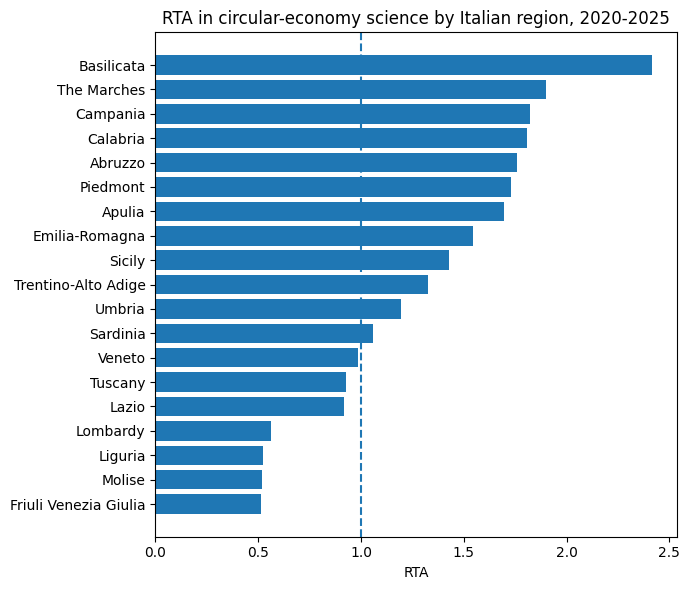

In [27]:
# Bar chart of the regional RCA, regions sorted by RCA; the dashed line (RCA = 1) is the Italian average
plt.figure(figsize=(7, 6))
plt.barh(rca_region.index[::-1], rca_region["rca"][::-1])
plt.axvline(1, linestyle="--")
plt.title("RCA in circular-economy science by Italian region, 2020-2025")
plt.xlabel("RCA")
plt.tight_layout(); plt.show()

**Interpret.**

- Raw counts (second table): China leads with about 19,400 CE works in 2020-2025, the United States is a distant second (8,500), Russia third (7,200); Italy is ninth with 3,400.
- The RCA (third table and chart) reorders them: Russia (2.8) is by far the most specialised large producer, because the set's industrial-waste, metallurgy and mineral-processing topics live in Russian applied journals. China (1.3), Brazil (1.2) and India (1.1) publish more than their size predicts; Italy (1.09) sits just above the world average, highest among the large western European producers; the United States (0.45) far below.
- The topic set decides the answer: the earlier 28-topic keyword-rule build had Indonesia fourth (RCA 1.25) and Russia nowhere. Whatever set you use, state it next to the results.
- Regional RCAs rest on institution counts: they double count multi-institution papers, they inherit institution disambiguation errors, and they needed the city patch. Read them as illustrative.
- With the patch, southern and central regions lead: Basilicata 2.4, the Marches 1.9, Campania 1.8, Calabria 1.8, Abruzzo 1.8; Apulia, the region hosting this school, sits at 1.7, well above the Italian average. Lombardy (0.56), Liguria (0.52) and Molise (0.52) close the ranking; the Aosta Valley has no institution among the 200 largest and does not appear.

**Exercise.** Swap the topic set for `"T10471"` and redo the country RCA for climate economics.

## B3. SDG landscape: what are a country's research priorities?

**Concept.** OpenAlex tags works with the 17 UN Sustainable Development Goals (`sustainable_development_goals`; climate action is `https://openalex.org/sdgs/13`). Two questions, roughly one call each:

- a country's **SDG profile**: `group_by = "sustainable_development_goals.id"` for one country (the OpenAlex recipe "Map SDG research");
- its **revealed priorities**: the country's profile divided by the world's, goal by goal. This is the specialisation index of Confraria, Ciarli and Noyons (2024, *Research Policy* 53(3), doi:10.1016/j.respol.2023.104950), who read exactly such indices as countries' research priorities; they compute it on Web of Science with keyword-built SDG queries, we compute it on OpenAlex's classifier tags.

The partner country is China: the largest CE producer of B2, with a profile that differs from Italy's exactly where this school lives (energy, water, environment).

Caveat, planted in B0: SDG tags are classifier output, and databases and classifiers disagree on which papers count (Kashnitsky et al. 2024, *Quantitative Science Studies* 5(2), doi:10.1162/qss_a_00304; Ottaviani and Stahlschmidt 2024, arXiv:2405.03007).

In [28]:
# The SDG profile of a country: its works 2020-2025, counted by SDG tag (17 rows per country)
sdg_it = pd.DataFrame(Works().filter(authorships={"countries": "IT"}, publication_year="2020-2025")
                      .group_by("sustainable_development_goals.id").get())
sdg_cn = pd.DataFrame(Works().filter(authorships={"countries": "CN"}, publication_year="2020-2025")
                      .group_by("sustainable_development_goals.id").get())

# What we downloaded
sdg_it.head(5)
# sdg_cn.head(5)   # uncomment to inspect China's table too

,key,key_display_name,count
0,https://openalex.org/sdgs/3,Good health and well-being,227911
1,https://openalex.org/sdgs/2,Zero hunger,58024
2,https://openalex.org/sdgs/7,Affordable and clean energy,56572
3,https://openalex.org/sdgs/11,Sustainable cities and communities,38622
4,https://openalex.org/sdgs/14,Life below water,35892


In [29]:
# One clean table per country: SDG number from the key URL (".../sdgs/13" -> 13), goal name, count
it = pd.DataFrame({"sdg_n": sdg_it["key"].str.split("/").str[-1].astype(int),
                   "goal":  sdg_it["key_display_name"],
                   "n_it":  sdg_it["count"]})
cn = pd.DataFrame({"sdg_n": sdg_cn["key"].str.split("/").str[-1].astype(int),
                   "n_cn":  sdg_cn["count"]})

# Merge 1:1 on the goal
sdg = it.merge(cn, on="sdg_n")

# Shares of national output: what fraction of a country's works carries each tag.
# The totals come from B2's country table (all_c).
tot_it = all_c.loc[all_c["country"] == "IT", "all"].iloc[0]
tot_cn = all_c.loc[all_c["country"] == "CN", "all"].iloc[0]
sdg["share_it"] = 100 * sdg["n_it"] / tot_it
sdg["share_cn"] = 100 * sdg["n_cn"] / tot_cn

sdg.sort_values("share_it", ascending=False)

,sdg_n,goal,n_it,n_cn,share_it,share_cn
0,3,Good health and well-being,227911,818781,16.738101,12.224754
1,2,Zero hunger,58024,296385,4.261363,4.425156
2,7,Affordable and clean energy,56572,680051,4.154726,10.153455
3,11,Sustainable cities and communities,38622,209151,2.836453,3.122715
4,14,Life below water,35892,191019,2.635958,2.851996
5,10,Reduced inequalities,34573,109112,2.539089,1.629089
6,4,Quality education,30756,124734,2.258763,1.862332
7,9,"Industry, innovation and infrastructure",30023,183739,2.204931,2.743303
8,16,"Peace, justice, and strong institutions",30013,113328,2.204196,1.692036
9,15,Life on land,26967,184079,1.980494,2.748379


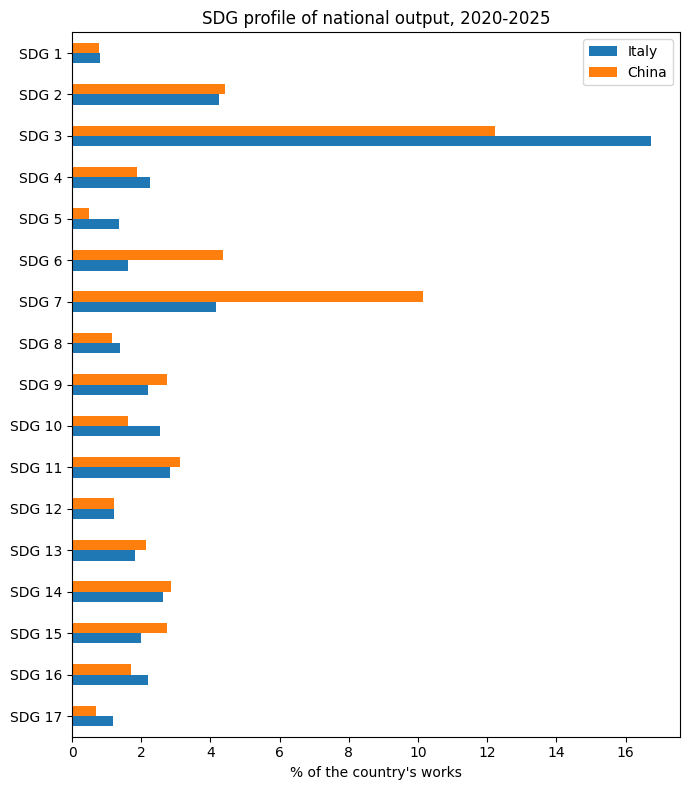

In [30]:
# One bar per goal and country; horizontal so all 17 goal labels are readable, SDG 1 on top (Stata: graph hbar)
wide = sdg.set_index("sdg_n")[["share_it", "share_cn"]].sort_index()
wide.index = ["SDG " + str(n) for n in wide.index]
wide.columns = ["Italy", "China"]

wide.iloc[::-1].plot.barh(figsize=(7, 8))
plt.xlabel("% of the country's works")
plt.title("SDG profile of national output, 2020-2025")
plt.tight_layout(); plt.show()

In [31]:
# Revealed research priorities (Confraria, Ciarli and Noyons 2024, eq. 1): for each goal,
# the country's share of its SDG-tagged output over the world's share of world SDG-tagged output.
# Above 1: the country leans on that goal more than world science does.

# The world's SDG profile: the same call, with no country filter
sdg_world = pd.DataFrame(Works().filter(publication_year="2020-2025")
                         .group_by("sustainable_development_goals.id").get())
world = pd.DataFrame({"sdg_n":   sdg_world["key"].str.split("/").str[-1].astype(int),
                      "n_world": sdg_world["count"]})

# Merge and divide
sdg = sdg.merge(world, on="sdg_n")
sdg["priority_it"] = (sdg["n_it"] / sdg["n_it"].sum()) / (sdg["n_world"] / sdg["n_world"].sum())
sdg["priority_cn"] = (sdg["n_cn"] / sdg["n_cn"].sum()) / (sdg["n_world"] / sdg["n_world"].sum())

# Priorities, Italy's highest first
sdg[["sdg_n", "goal", "priority_it", "priority_cn"]].sort_values("priority_it", ascending=False)

,sdg_n,goal,priority_it,priority_cn
0,3,Good health and well-being,1.621386,1.117029
14,12,Responsible consumption and production,1.547015,1.469611
4,14,Life below water,1.380921,1.409365
3,11,Sustainable cities and communities,1.158440,1.203024
15,17,Partnerships for the goals,1.089530,0.617001
9,15,Life on land,1.087789,1.423941
16,1,No poverty,1.051174,0.930772
7,9,"Industry, innovation and infrastructure",1.037843,1.218021
10,13,Climate action,1.023208,1.139889
2,7,Affordable and clean energy,0.960413,2.213979


**Interpret.**

- Health dominates both profiles: SDG 3 tags 16.7 percent of Italian works and 12.2 of Chinese. The green goals split the two countries: China puts 10.2 percent of its output on affordable and clean energy (SDG 7) against Italy's 4.2, and 4.4 percent on clean water and sanitation (SDG 6) against Italy's 1.6. One sentence for the room: a coal-heavy energy mix and large state decarbonisation and pollution programmes pull Chinese research toward energy and environmental engineering; Italian output tilts biomedical.
- The priority table reads the same contrast against world science instead of country size: values above 1 mark the goals a country leans on more than the world does. Italy's top revealed priorities are health (1.6), **responsible consumption and production (SDG 12, 1.55)**, the circular-economy goal, an echo of this whole session, and life below water (1.4); China's are affordable and clean energy (2.2) and clean water (2.2). This is the measure of Confraria, Ciarli and Noyons (2024) in miniature: same index, different database and SDG classifier, so levels differ from their paper even where the story agrees.
- All of it is a classifier's reading: repeat the profile with the Scopus or Web of Science SDG filters and the rankings move. That is not a footnote, it is the B0 lesson at country scale.

**Exercise.** Replace China with your own country (or with Indonesia, whose profile is the most different from Italy's in the whole database, largely an artefact of locally indexed education journals) and find its top revealed priority.